# Loading data and importing libraries

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Setting plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

In [6]:
# Set display option to show all columns in one line
pd.set_option('display.max_columns', None)          # Show all columns
pd.set_option('display.expand_frame_repr', False)   # Dont wrap dataframe across lines
pd.set_option('display.width', 1000)                # Set high full width limit to prevent line breaks
pd.set_option('display.max_colwidth', None)         # Show full column content

In [7]:
df = pd.read_excel('Online Retail.xlsx')
print("Dataset loaded successfully")

Dataset loaded successfully


In [8]:
print("\n---initial dataframe Info ---\n")
df.info()


---initial dataframe Info ---

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [9]:
print("\n--- First 5 rows ---\n")
df.head()


--- First 5 rows ---



,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [10]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [11]:
df.describe(include = 'object')

,InvoiceNo,StockCode,Description,Country
count,541909,541909,540455,541909
unique,25900,4070,4223,38
top,573585,85123A,WHITE HANGING HEART T-LIGHT HOLDER,United Kingdom
freq,1114,2313,2369,495478


# Data Cleaning and Preprocessing

### Removal of duplicates

In [12]:
initial_rows = df.shape[0]
print(f"Initial rows in dataframe {initial_rows}")

df.drop_duplicates(inplace = True)
print(f"\nRemoved {initial_rows - df.shape[0]} duplicate rows")

Initial rows in dataframe 541909

Removed 5268 duplicate rows


### Handle missing values

In [13]:
print(f"Rows before dropping {df.shape[0]}")
# Drop where 'description' is missing
df.dropna(subset = ['Description'], inplace = True)
print(f"Rows after dropping 'Description': {df.shape[0]}")

Rows before dropping 536641
Rows after dropping 'Description': 535187


In [14]:
# Drop where 'Customer ID' is missing (Crucial for customer analysis)
df.dropna(subset = ['CustomerID'], inplace = True)
print(f"Rows after dropping 'Customer ID': {df.shape[0]}")

Rows after dropping 'Customer ID': 401604


### Clean Quantity and unit price

In [15]:
# Filter out returns (Quantity < 0)
df = df[df['Quantity'] > 0]
print(f"Rows after filtering out negative Quantity: {df.shape[0]}")

Rows after filtering out negative Quantity: 392732


In [16]:
# Filter out returns (Price < 0)
df = df[df['UnitPrice'] > 0]
print(f"Rows after filtering out negative UnitPrices: {df.shape[0]}")

Rows after filtering out negative UnitPrices: 392692


### Convert Data Types:

In [17]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['CustomerID'] = df['CustomerID'].astype(str)
print("\nData types after conversion:")
df.info()


Data types after conversion:
<class 'pandas.core.frame.DataFrame'>
Index: 392692 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392692 non-null  object        
 1   StockCode    392692 non-null  object        
 2   Description  392692 non-null  object        
 3   Quantity     392692 non-null  int64         
 4   InvoiceDate  392692 non-null  datetime64[ns]
 5   UnitPrice    392692 non-null  float64       
 6   CustomerID   392692 non-null  object        
 7   Country      392692 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(5)
memory usage: 27.0+ MB


### Feature Engineering

In [21]:
df['Revenue'] = df['Quantity'] * df['UnitPrice']
df['InvoiceYear'] = df['InvoiceDate'].dt.year
df['InvoiceMonth'] = df['InvoiceDate'].dt.month_name()
df['InvoiceDay'] = df['InvoiceDate'].dt.day
df['InvoiceDayOfWeek'] = df['InvoiceDate'].dt.day_name()
df['InvoiceHour'] = df['InvoiceDate'].dt.hour
df['InvoiceQuarter'] = df['InvoiceDate'].dt.quarter.astype(str) + 'Q'

In [20]:
print("\nDataframe after new engineered features:")
df.head()


Dataframe after new engineered features:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,InvoiceYear,InvoiceMonth,InvoiceDay,InvoiceDayOfWeek,InvoiceHour,InvoiceQuarter
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010,December,1,Wednesday,8,4Q
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,December,1,Wednesday,8,4Q
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010,December,1,Wednesday,8,4Q
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,December,1,Wednesday,8,4Q
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,December,1,Wednesday,8,4Q


In [23]:
print("Final Dataframe shape after all cleaning and feature engineering:", df.shape)

Final Dataframe shape after all cleaning and feature engineering: (392692, 15)


# Exploratory Data Analysis (EDA) & Visualization

### Overall Sales Performance:

In [25]:
print(f"Total Revenue: £{sum(df['Revenue'])} million")
print(f"Total Unique Customers: {df['CustomerID'].nunique()}")
print(f"Total Unique Products: {df['StockCode'].nunique()}")

Total Revenue: £8887208.894003171 million
Total Unique Customers: 4338
Total Unique Products: 3665


### Time-Based Sales Trends:

In [ ]:
# Resampling the time series data based on months at end
# 'Me' indicated end of month
monthly_sales = df.set_index('InvoiceDate')['Revenue'].resample('ME').sum()
monthly_sales

InvoiceDate
2010-12-31     570422.730
2011-01-31     568101.310
2011-02-28     446084.920
2011-03-31     594081.760
2011-04-30     468374.331
2011-05-31     677355.150
2011-06-30     660046.050
2011-07-31     598962.901
2011-08-31     644051.040
2011-09-30     950690.202
2011-10-31    1035642.450
2011-11-30    1156205.610
2011-12-31     517190.440
Freq: ME, Name: Revenue, dtype: float64

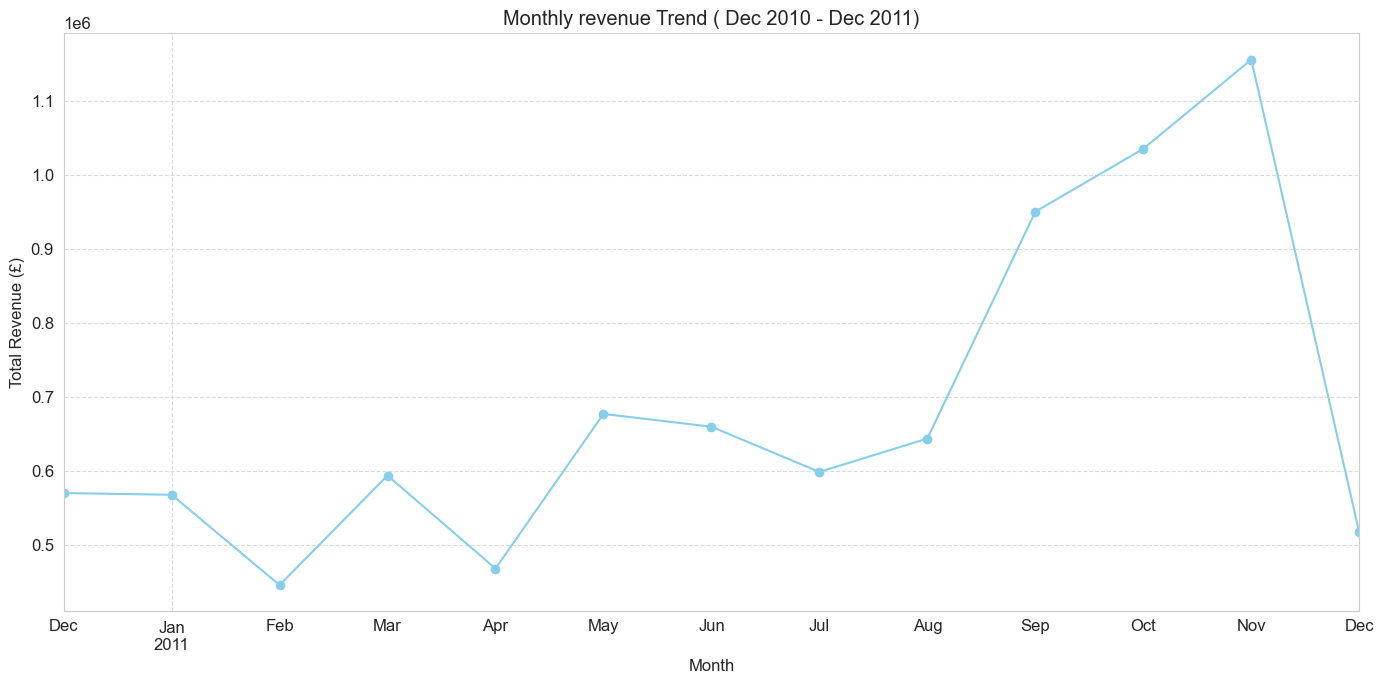

In [29]:
plt.figure(figsize = (14, 7))
monthly_sales.plot(kind = 'line', marker = 'o', color = 'skyblue')
plt.title("Monthly revenue Trend ( Dec 2010 - Dec 2011)")
plt.xlabel('Month')
plt.ylabel('Total Revenue (£)')
plt.grid(True, linestyle = '--', alpha = 0.7)
plt.tight_layout()
plt.show()

### Daily Sales by Day of Week

In [31]:
day_of_week_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sales_by_day_of_week = df.groupby('InvoiceDayOfWeek')['Revenue'].sum().reindex(day_of_week_order)
sales_by_day_of_week

InvoiceDayOfWeek
Monday       1363604.401
Tuesday      1697733.801
Wednesday    1584283.830
Thursday     1973015.730
Friday       1483080.811
Saturday             NaN
Sunday        785490.321
Name: Revenue, dtype: float64

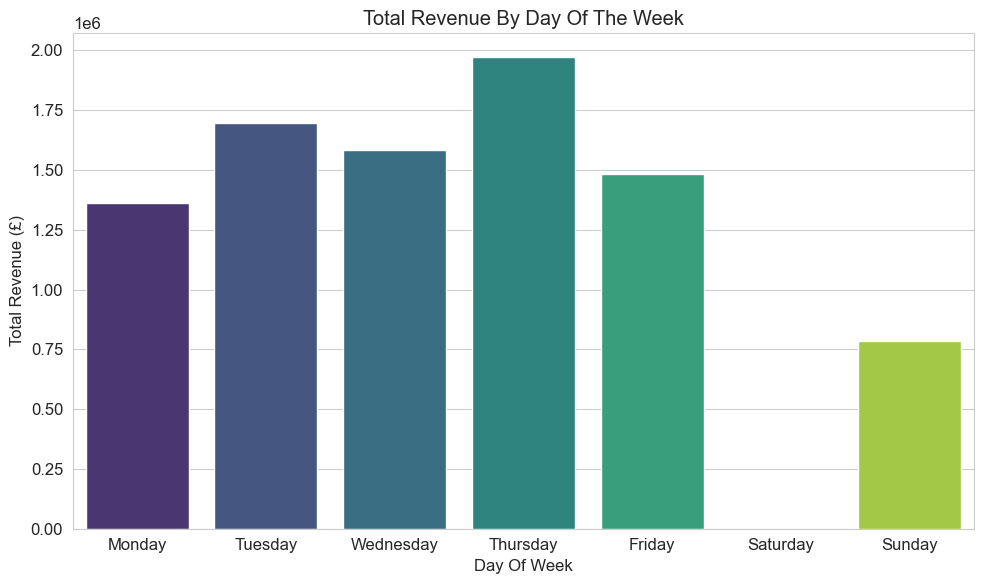

In [36]:
plt.figure(figsize = (10, 6))
sns.barplot(x = sales_by_day_of_week.index, y = sales_by_day_of_week.values, hue = sales_by_day_of_week.index, palette = 'viridis')
plt.title("Total Revenue By Day Of The Week")
plt.xlabel('Day Of Week')
plt.ylabel('Total Revenue (£)')
plt.tight_layout()
plt.show()